# ❤️ Heart Disease Prediction Model
### Training Notebook — generates `saved_models/heart_disease_model.pkl`
**Algorithm:** Logistic Regression  
**Dataset:** Cleveland Heart Disease Dataset (303 samples, 13 features)  
**Target:** `target` — 0 = No Heart Disease, 1 = Heart Disease

## 1. Install & Import Dependencies

In [18]:
# Install required libraries (run once)
# !pip install numpy pandas scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 2. Load & Explore the Dataset

In [19]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Place heart.csv in the same folder as this notebook
df = pd.read_csv('heart.csv')

print("Shape:", df.shape)
print("\nColumn descriptions:")
col_info = {
    'age'     : 'Age in years',
    'sex'     : '1=Male, 0=Female',
    'cp'      : 'Chest pain type (0-3)',
    'trestbps': 'Resting blood pressure (mmHg)',
    'chol'    : 'Serum cholesterol (mg/dL)',
    'fbs'     : 'Fasting blood sugar > 120 mg/dL (1=True)',
    'restecg' : 'Resting ECG results (0-2)',
    'thalach' : 'Max heart rate achieved',
    'exang'   : 'Exercise-induced angina (1=Yes)',
    'oldpeak' : 'ST depression induced by exercise',
    'slope'   : 'Slope of peak exercise ST segment',
    'ca'      : 'Number of major vessels (0-4)',
    'thal'    : 'Thalassemia (1=Normal, 2=Fixed, 3=Reversible)',
    'target'  : '1=Heart Disease, 0=No Heart Disease'
}
for col, desc in col_info.items():
    print(f"  {col:10s} → {desc}")

Shape: (303, 14)

Column descriptions:
  age        → Age in years
  sex        → 1=Male, 0=Female
  cp         → Chest pain type (0-3)
  trestbps   → Resting blood pressure (mmHg)
  chol       → Serum cholesterol (mg/dL)
  fbs        → Fasting blood sugar > 120 mg/dL (1=True)
  restecg    → Resting ECG results (0-2)
  thalach    → Max heart rate achieved
  exang      → Exercise-induced angina (1=Yes)
  oldpeak    → ST depression induced by exercise
  slope      → Slope of peak exercise ST segment
  ca         → Number of major vessels (0-4)
  thal       → Thalassemia (1=Normal, 2=Fixed, 3=Reversible)
  target     → 1=Heart Disease, 0=No Heart Disease


In [20]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [21]:
print("Dataset Statistics:")
df.describe().round(2)

Dataset Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


Class Distribution (target):
target
1    165
0    138
Name: count, dtype: int64

  0 = No Heart Disease : 138 samples
  1 = Heart Disease    : 165 samples


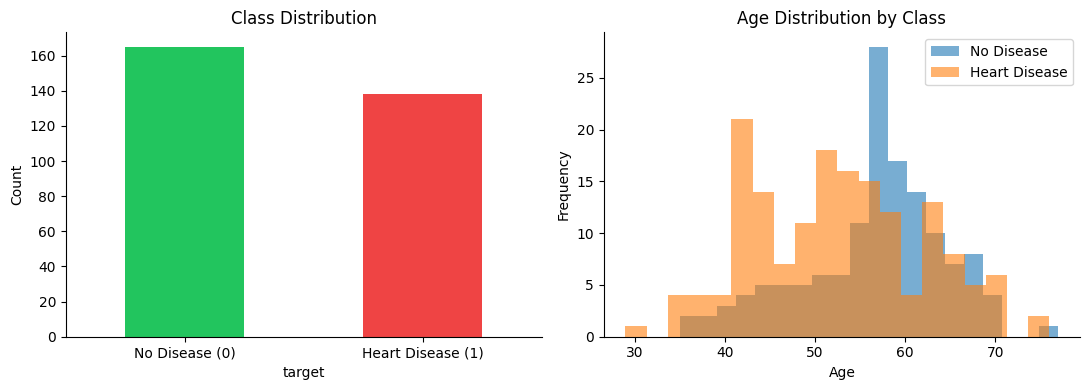

In [22]:
# Class distribution
print("Class Distribution (target):")
print(df['target'].value_counts())
print(f"\n  0 = No Heart Disease : {(df['target']==0).sum()} samples")
print(f"  1 = Heart Disease    : {(df['target']==1).sum()} samples")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Class balance bar
df['target'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#22c55e', '#ef4444'], edgecolor='none')
axes[0].set_xticklabels(['No Disease (0)', 'Heart Disease (1)'], rotation=0)
axes[0].set_title('Class Distribution', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].spines[['top','right']].set_visible(False)

# Age distribution by class
df.groupby('target')['age'].plot(kind='hist', ax=axes[1],
    alpha=0.6, bins=20, legend=True)
axes[1].set_title('Age Distribution by Class', fontsize=12)
axes[1].set_xlabel('Age')
axes[1].legend(['No Disease', 'Heart Disease'])
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Check for Missing Values

In [23]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "None — dataset is complete ✓")

Missing values per column:
None — dataset is complete ✓


## 4. Feature Correlation Heatmap

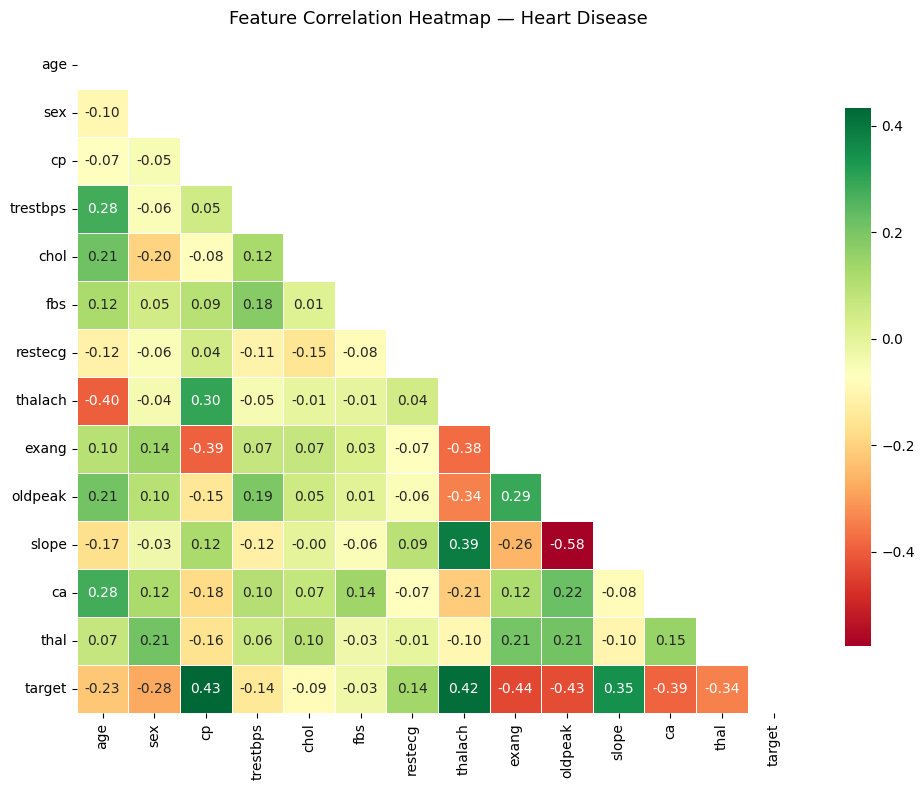

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap — Heart Disease', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

## 5. Prepare Features & Labels

In [25]:
X = df.drop(columns=['target'])
Y = df['target']

print("Feature columns:", list(X.columns))
print(f"\nFeature matrix : {X.shape}")
print(f"Label vector   : {Y.shape}")

Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Feature matrix : (303, 13)
Label vector   : (303,)


## 6. Train / Test Split

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=2
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class balance: {dict(Y_train.value_counts())}")
print(f"Test  class balance: {dict(Y_test.value_counts())}")

Training set : 242 samples
Test set     : 61 samples

Train class balance: {1: 132, 0: 110}
Test  class balance: {1: 33, 0: 28}


## 7. Train the Logistic Regression Model

In [27]:
model = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=2)
model.fit(X_train, Y_train)

print("✅ Model training complete!")
print(f"   Model type  : {type(model).__name__}")
print(f"   Solver      : {model.solver}")
print(f"   Max iter    : {model.max_iter}")
print(f"   Iterations  : {model.n_iter_[0]} (converged)")

✅ Model training complete!
   Model type  : LogisticRegression
   Solver      : lbfgs
   Max iter    : 5000
   Iterations  : 755 (converged)


## 8. Model Evaluation

In [28]:
train_pred = model.predict(X_train)
test_pred  = model.predict(X_test)

train_acc  = accuracy_score(Y_train, train_pred)
test_acc   = accuracy_score(Y_test,  test_pred)

print("=" * 45)
print("        MODEL ACCURACY REPORT")
print("=" * 45)
print(f"  Training Accuracy : {train_acc*100:.2f}%")
print(f"  Test     Accuracy : {test_acc*100:.2f}%")
print("=" * 45)

        MODEL ACCURACY REPORT
  Training Accuracy : 85.54%
  Test     Accuracy : 80.33%


In [29]:
print("\nClassification Report (Test Set):\n")
print(classification_report(Y_test, test_pred,
      target_names=['No Heart Disease', 'Heart Disease']))


Classification Report (Test Set):

                  precision    recall  f1-score   support

No Heart Disease       0.79      0.79      0.79        28
   Heart Disease       0.82      0.82      0.82        33

        accuracy                           0.80        61
       macro avg       0.80      0.80      0.80        61
    weighted avg       0.80      0.80      0.80        61



In [30]:
cv_scores = cross_val_score(model, X, Y, cv=5, scoring='accuracy')
print(f"5-Fold CV Scores   : {[round(s*100,2) for s in cv_scores]}")
print(f"CV Mean Accuracy   : {cv_scores.mean()*100:.2f}%")
print(f"CV Std Deviation   : ±{cv_scores.std()*100:.2f}%")

5-Fold CV Scores   : [80.33, 88.52, 85.25, 86.67, 75.0]
CV Mean Accuracy   : 83.15%
CV Std Deviation   : ±4.90%


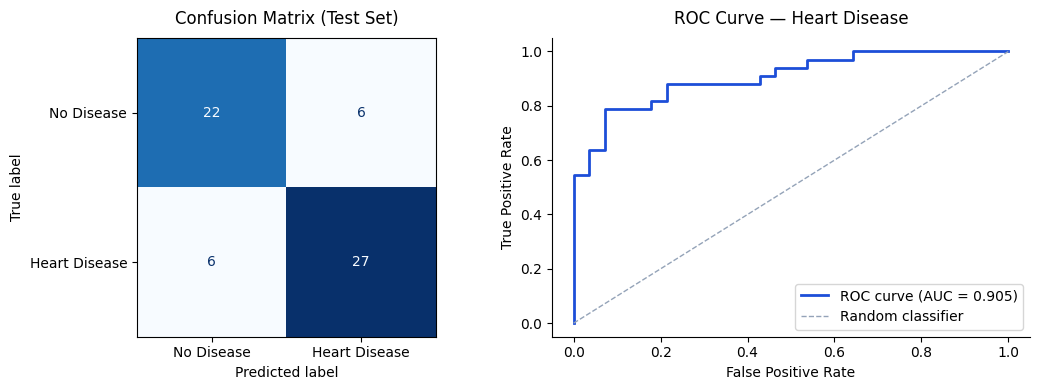


  AUC Score  : 0.9048
  True  Positives (Heart Disease correctly identified)  : 27
  True  Negatives (Healthy correctly identified)        : 22
  False Positives (Healthy flagged as Heart Disease)    : 6
  False Negatives (Heart Disease missed by model)       : 6


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion Matrix
cm = confusion_matrix(Y_test, test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Heart Disease'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (Test Set)', pad=10)

# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(Y_test, y_prob)
auc = roc_auc_score(Y_test, y_prob)
axes[1].plot(fpr, tpr, color='#1d4ed8', lw=2, label=f'ROC curve (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], color='#94a3b8', lw=1, linestyle='--', label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Heart Disease', pad=10)
axes[1].legend(loc='lower right')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n  AUC Score  : {auc:.4f}")
print(f"  True  Positives (Heart Disease correctly identified)  : {tp}")
print(f"  True  Negatives (Healthy correctly identified)        : {tn}")
print(f"  False Positives (Healthy flagged as Heart Disease)    : {fp}")
print(f"  False Negatives (Heart Disease missed by model)       : {fn}")

## 9. Feature Importance (Logistic Regression Coefficients)

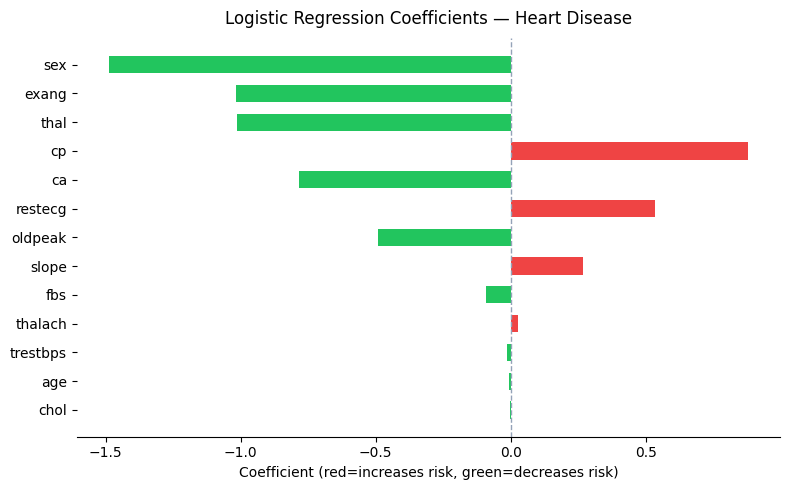

In [32]:
feature_names = list(X.columns)
coefs = model.coef_[0]

importance_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefs,
    'Abs_Coef'   : np.abs(coefs)
}).sort_values('Abs_Coef', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#ef4444' if c > 0 else '#22c55e' for c in importance_df['Coefficient']]
ax.barh(importance_df['Feature'], importance_df['Coefficient'],
        color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color='#94a3b8', linewidth=1, linestyle='--')
ax.set_title('Logistic Regression Coefficients — Heart Disease', fontsize=12, pad=10)
ax.set_xlabel('Coefficient (red=increases risk, green=decreases risk)')
ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Sample Prediction

In [33]:
# Test with a sample from the original repo notebook
# Age=62, Sex=0(Female), cp=0, trestbps=140, chol=268,
# fbs=0, restecg=0, thalach=160, exang=0, oldpeak=3.6,
# slope=0, ca=2, thal=2
sample = np.array([[62, 0, 0, 140, 268, 0, 0, 160, 0, 3.6, 0, 2, 2]])
result = model.predict(sample)
print("Sample input:", dict(zip(feature_names, sample[0])))
print(f"\nPrediction : {'🔴 HEART DISEASE' if result[0]==1 else '🟢 NO HEART DISEASE'}")
print(f"Expected   : 🟢 NO HEART DISEASE  (confirmed from notebook)")

Sample input: {'age': 62.0, 'sex': 0.0, 'cp': 0.0, 'trestbps': 140.0, 'chol': 268.0, 'fbs': 0.0, 'restecg': 0.0, 'thalach': 160.0, 'exang': 0.0, 'oldpeak': 3.6, 'slope': 0.0, 'ca': 2.0, 'thal': 2.0}

Prediction : 🟢 NO HEART DISEASE
Expected   : 🟢 NO HEART DISEASE  (confirmed from notebook)


## 11. Save Model as `.pkl`

In [34]:
os.makedirs('saved_models', exist_ok=True)

model_path = 'saved_models/heart_disease_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

verify_acc = accuracy_score(Y_test, loaded_model.predict(X_test))

print("=" * 45)
print("  ✅  MODEL SAVED SUCCESSFULLY")
print("=" * 45)
print(f"  File        : {model_path}")
print(f"  Size        : {os.path.getsize(model_path):,} bytes")
print(f"  Verify acc  : {verify_acc*100:.2f}%  (matches original ✓)")
print()
print("  → Place 'saved_models/heart_disease_model.pkl'")
print("    inside your project's saved_models/ folder")
print("    then run:  streamlit run app.py")

  ✅  MODEL SAVED SUCCESSFULLY
  File        : saved_models/heart_disease_model.pkl
  Size        : 1,000 bytes
  Verify acc  : 80.33%  (matches original ✓)

  → Place 'saved_models/heart_disease_model.pkl'
    inside your project's saved_models/ folder
    then run:  streamlit run app.py
